<a href="https://colab.research.google.com/github/AndySGL/bot/blob/main/Copia_de_la_copia_de_%5BESP%5D_Model_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip ./converted_keras.zip

Archive:  ./converted_keras.zip
 extracting: keras_model.h5          
 extracting: labels.txt              


In [ ]:
import PIL
PIL.__version__

'11.3.0'

In [ ]:
!pip install -q tf-keras==2.19.0 h5py==3.11.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.5/406.5 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement tensorflow<2.20,>=2.19 (from tf-keras) (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.20,>=2.19


In [ ]:
from google.colab import files

path = files.upload()
path = list(path.keys())[0]
image=PIL.Image.open(path)

Saving images (20).jpg to images (20).jpg


In [ ]:
import tf_keras as keras  # Importando tf-keras – una versión de Keras compatible con modelos .h5
from tf_keras.models import load_model  # Importando la función load_model de tf_keras, que nos permite abrir el modelo
from PIL import Image, ImageOps  # Instalando pillow en vez de PIL
import numpy as np

# Deshabilitar la notación científica para mayor claridad
np.set_printoptions(suppress=True)

# Cargando el modelo
model = load_model("keras_model.h5", compile=False)

# Cargando las etiquetas
class_names = open("labels.txt", "r").readlines()

# Creación de la matriz con la forma correcta para alimentar el modelo Keras
# La longitud, o número de imágenes que se pueden incluir en la matriz,
# está determinada por la primera posición en la tupla de forma (en este caso, 1).
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

# Reemplace esto con la ruta a su imagen
image = image.convert("RGB")

# Redimensionar la imagen para que tenga al menos 224x224px y luego recortarla desde el centro
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# Convertir la imagen en una matriz NumPy
image_array = np.asarray(image)

# Normalizando la imagen
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# Cargando la imagen dentro del array
data[0] = normalized_image_array

# Prediciendo con el modelo
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Imprimir predicción y puntuación de confianza
print("Class:", class_name[2:], end="")
print("Confidence Score:", confidence_score)


1/1 [==============================] - 1s 950ms/step
Class: Peces
Confidence Score: 0.5540586


Here's what you can give to pigeons: chickpeas, wheat, barley, seeds, buckwheat, millet, peas, lentils and other cereals in dry form.

Here's what you can give to sparrows: cracked corn, cereal grains, oats, wheat, rice, and dried insects

In [ ]:
def detect_bird(image, model, labels):
    np.set_printoptions(suppress=True)

    # Cargar el modelo
    model = load_model(model, compile=False)

    # Cargar las etiquetas
    class_names = open(labels, "r").readlines()

    # Crear la matriz para la imagen
    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

    # Convertir la imagen a RGB
    image = image.convert("RGB")

    # Guardar una copia para mostrarla
    display_image = image.copy()

    # Redimensionar la imagen
    size = (224, 224)
    image = ImageOps.fit(
        image,
        size,
        Image.Resampling.LANCZOS
    )

    # Convertir la imagen a matriz
    image_array = np.asarray(image)

    # Normalizar la imagen
    normalized_image_array = (
        image_array.astype(np.float32) / 127.5
    ) - 1

    # Guardar la imagen en el array
    data[0] = normalized_image_array

    # Hacer la predicción
    prediction = model.predict(data, verbose=0)

    # Obtener la clase con mayor probabilidad
    index = np.argmax(prediction)

    # Obtener nombre de la clase
    class_name = class_names[index]

    # Obtener confianza
    confidence_score = prediction[0][index]

    # Mostrar la imagen
    display(display_image)

    # Mostrar resultado
    print("===================================")
    print("       RESULTADO DEL MODELO")
    print("===================================")
    print("Animal detectado:", class_name[2:].strip())
    print("Confianza:", f"{confidence_score * 100:.2f}%")

    return class_name[2:].strip(), confidence_score

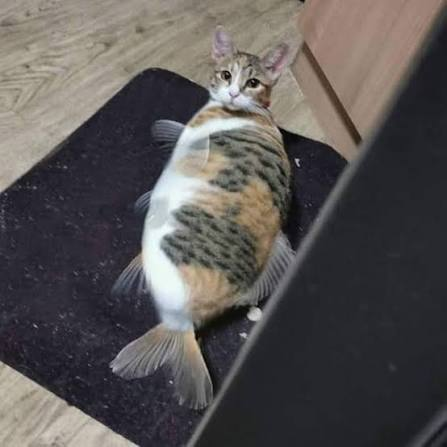

       RESULTADO DEL MODELO
Animal detectado: Peces
Confianza: 55.41%


('Peces', np.float32(0.5540586))

In [ ]:
image = Image.open("images (20).jpg")

detect_bird(image, "keras_model.h5", "labels.txt")